# 🖼️ Image Recognition Model — CIFAR-10
**CNN-based classifier for animals, birds, and vehicles**

Classes: `airplane · automobile · bird · cat · deer · dog · frog · horse · ship · truck`

---
Author: Ali Hamza | GitHub: [alihamza701](https://github.com/alihamza701)

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import time
import os

# Device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 2. Data Loading & Augmentation

In [2]:
# CIFAR-10 class names
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# --- Training transforms (with augmentation) ---
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

# --- Test transforms (no augmentation) ---
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

# Download CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                              download=True, transform=test_transform)

# Split train → train + validation (80/20)
val_size   = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {train_size} | Val: {val_size} | Test: {len(test_dataset)}')

100%|██████████| 170M/170M [00:03<00:00, 45.6MB/s]


Train: 40000 | Val: 10000 | Test: 10000


## 3. Visualize Sample Images

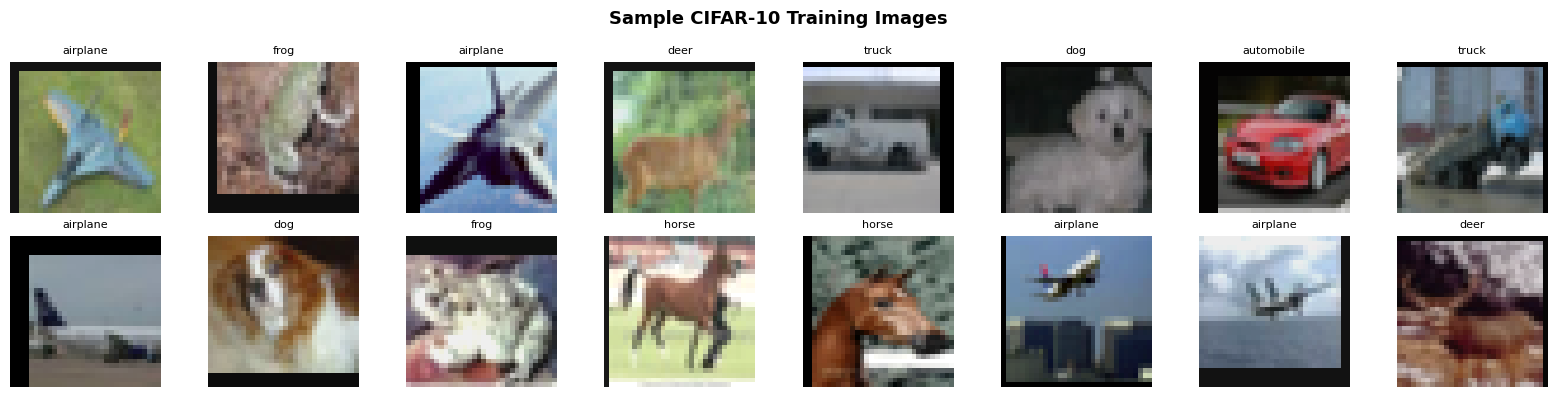

In [3]:
def denormalize(tensor):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)
    return tensor * std + mean

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Training Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Model Architecture — Enhanced CNN

We use **Batch Normalization** and **Dropout** for regularization, and **residual-style skip connections** for better gradient flow.

In [4]:
class ConvBlock(nn.Module):
    """Conv → BN → ReLU block."""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class ImageRecognitionCNN(nn.Module):
    """
    Enhanced CNN for CIFAR-10.
    Architecture:
      Block 1: 3  → 64  channels, MaxPool
      Block 2: 64 → 128 channels, MaxPool
      Block 3: 128→ 256 channels, MaxPool
      Classifier: FC(1024) → Dropout → FC(512) → Dropout → FC(10)
    """
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            ConvBlock(3,   64),
            ConvBlock(64,  64),
            nn.MaxPool2d(2, 2),   # 32 → 16
            nn.Dropout2d(0.1),

            # Block 2
            ConvBlock(64,  128),
            ConvBlock(128, 128),
            nn.MaxPool2d(2, 2),   # 16 → 8
            nn.Dropout2d(0.2),

            # Block 3
            ConvBlock(128, 256),
            ConvBlock(256, 256),
            nn.MaxPool2d(2, 2),   # 8 → 4
            nn.Dropout2d(0.3),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = ImageRecognitionCNN(num_classes=10).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')
print(model)

Model parameters: 5,871,562
ImageRecognitionCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
    (4): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): R

## 5. Training Setup — Loss, Optimizer & Scheduler

In [5]:
EPOCHS        = 30
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing helps generalization
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Cosine annealing LR scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'Criterion : CrossEntropyLoss (label_smoothing=0.1)')
print(f'Optimizer : AdamW (lr={LEARNING_RATE}, weight_decay=1e-4)')
print(f'Scheduler : CosineAnnealingLR (T_max={EPOCHS})')

Criterion : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : AdamW (lr=0.001, weight_decay=1e-4)
Scheduler : CosineAnnealingLR (T_max=30)


## 6. Training Loop with Validation & Early Stopping

In [6]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, 100. * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, 100. * correct / total


# Training loop
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc  = 0.0
patience      = 7
patience_counter = 0
SAVE_PATH     = 'best_model.pth'

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        patience_counter = 0
        tag = '✅ saved'
    else:
        patience_counter += 1
        tag = f'(patience {patience_counter}/{patience})'

    elapsed = time.time() - t0
    print(f'Epoch [{epoch:02d}/{EPOCHS}] | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | '
          f'{elapsed:.1f}s | {tag}')

    if patience_counter >= patience:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

print(f'\n✅ Best Validation Accuracy: {best_val_acc:.2f}%')

Epoch [01/30] | Train Loss: 1.9160 Acc: 32.20% | Val Loss: 1.6183 Acc: 49.33% | 37.8s | ✅ saved
Epoch [02/30] | Train Loss: 1.6411 Acc: 47.71% | Val Loss: 1.5188 Acc: 55.20% | 36.6s | ✅ saved
Epoch [03/30] | Train Loss: 1.5180 Acc: 54.78% | Val Loss: 1.3754 Acc: 60.00% | 37.3s | ✅ saved
Epoch [04/30] | Train Loss: 1.4332 Acc: 59.03% | Val Loss: 1.2943 Acc: 66.13% | 36.4s | ✅ saved
Epoch [05/30] | Train Loss: 1.3560 Acc: 63.21% | Val Loss: 1.2382 Acc: 67.88% | 35.5s | ✅ saved
Epoch [06/30] | Train Loss: 1.2963 Acc: 65.88% | Val Loss: 1.1860 Acc: 70.78% | 36.5s | ✅ saved
Epoch [07/30] | Train Loss: 1.2436 Acc: 68.51% | Val Loss: 1.1461 Acc: 72.39% | 36.9s | ✅ saved
Epoch [08/30] | Train Loss: 1.1937 Acc: 71.28% | Val Loss: 1.1609 Acc: 72.72% | 35.6s | ✅ saved
Epoch [09/30] | Train Loss: 1.1575 Acc: 72.47% | Val Loss: 1.0966 Acc: 75.32% | 35.7s | ✅ saved
Epoch [10/30] | Train Loss: 1.1219 Acc: 74.28% | Val Loss: 1.0356 Acc: 78.59% | 35.9s | ✅ saved
Epoch [11/30] | Train Loss: 1.0857 Acc: 

## 7. Training Curves

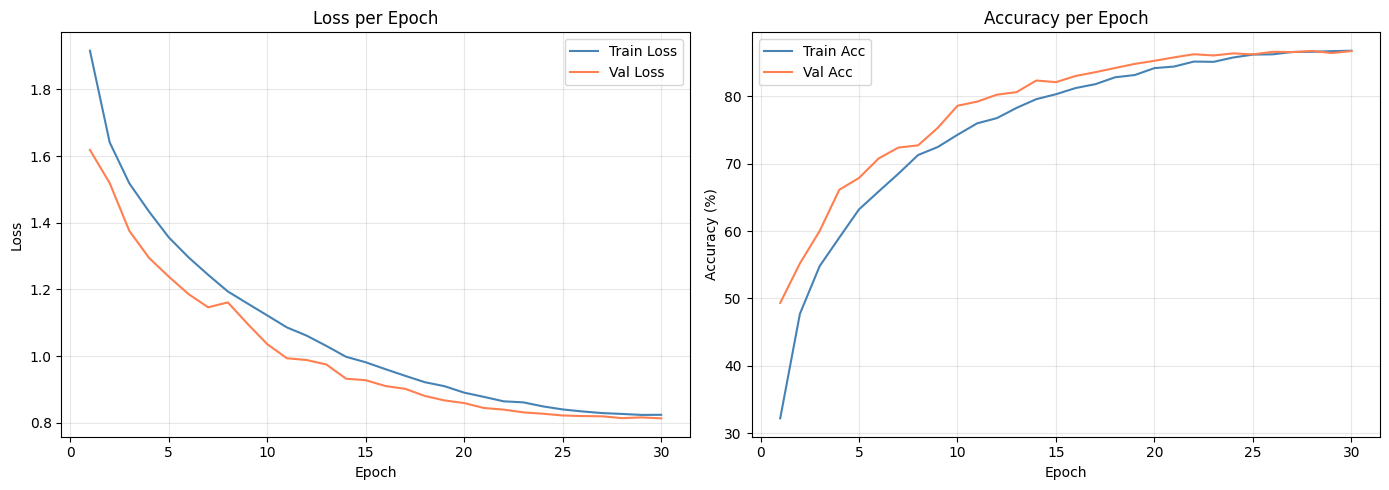

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_ran, history['train_loss'], label='Train Loss', color='steelblue')
ax1.plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='coral')
ax1.set_title('Loss per Epoch'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, history['train_acc'], label='Train Acc', color='steelblue')
ax2.plot(epochs_ran, history['val_acc'],   label='Val Acc',   color='coral')
ax2.set_title('Accuracy per Epoch'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation on Test Set

In [8]:
# Load best checkpoint
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f'Test Loss : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.2f}%')

Test Loss : 0.8010
Test Accuracy : 87.67%


## 9. Confusion Matrix & Classification Report

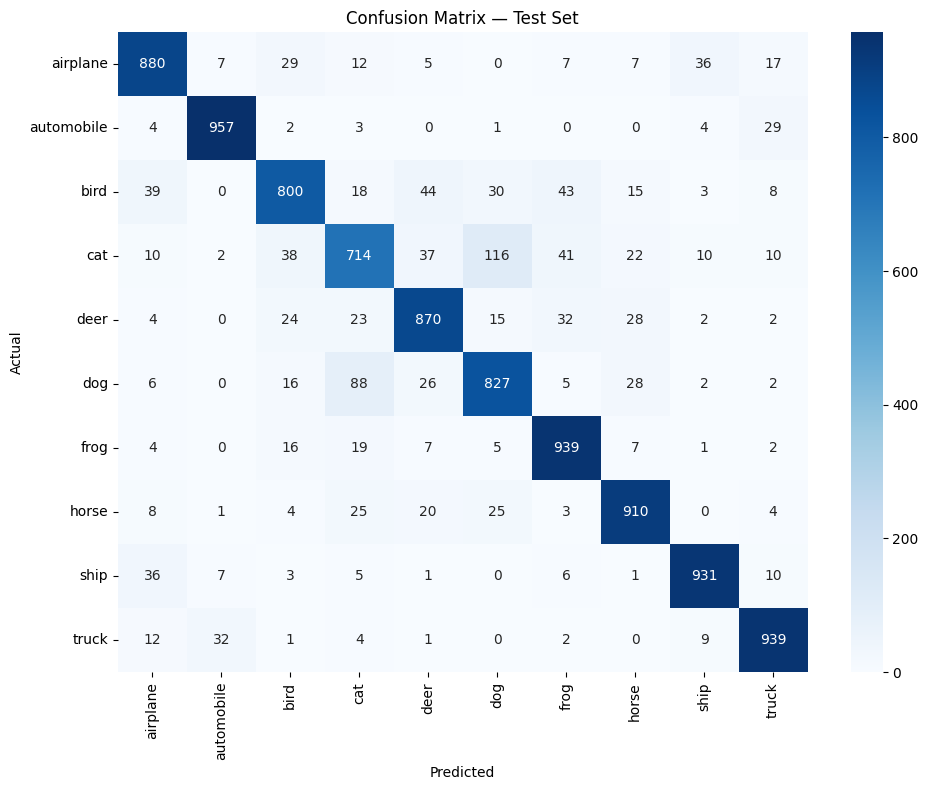


Classification Report:
              precision    recall  f1-score   support

    airplane       0.88      0.88      0.88      1000
  automobile       0.95      0.96      0.95      1000
        bird       0.86      0.80      0.83      1000
         cat       0.78      0.71      0.75      1000
        deer       0.86      0.87      0.87      1000
         dog       0.81      0.83      0.82      1000
        frog       0.87      0.94      0.90      1000
       horse       0.89      0.91      0.90      1000
        ship       0.93      0.93      0.93      1000
       truck       0.92      0.94      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [9]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_predictions(model, test_loader)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASSES))

## 10. Inference on Sample Images

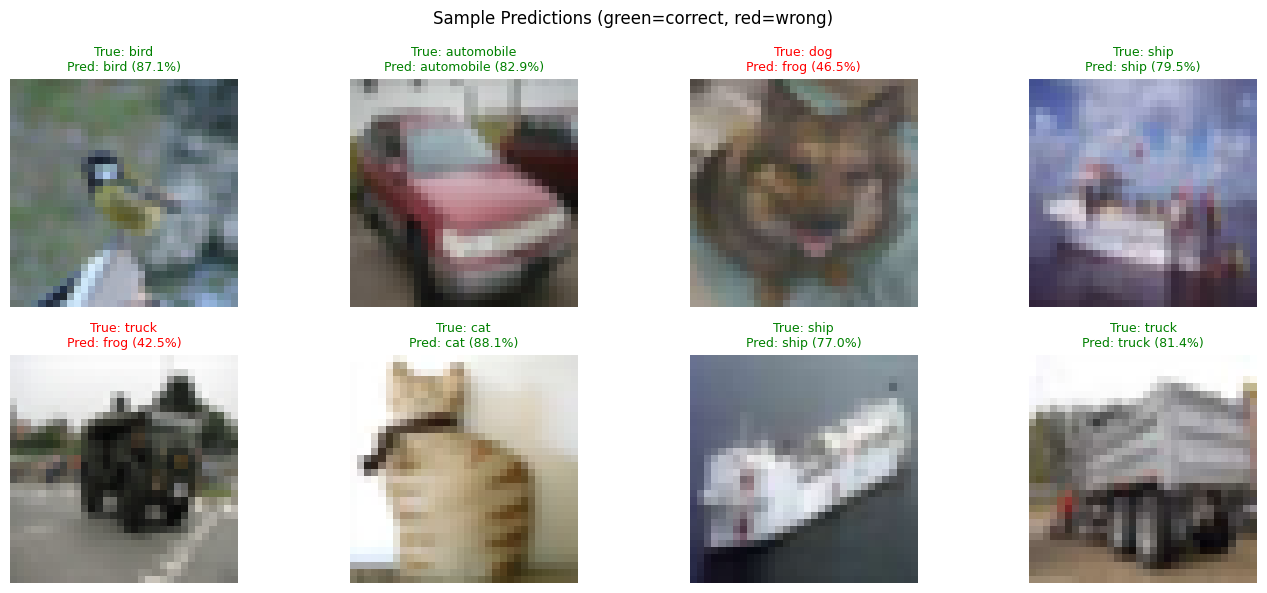

In [10]:
@torch.no_grad()
def predict_single(model, image_tensor):
    """Returns predicted class name and confidence."""
    model.eval()
    img = image_tensor.unsqueeze(0).to(device)
    logits = model(img)
    probs  = F.softmax(logits, dim=1).squeeze()
    conf, idx = probs.max(0)
    return CLASSES[idx.item()], conf.item(), probs.cpu().numpy()


# Visualize predictions on 8 random test images
raw_test = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=False, transform=test_transform)
indices = np.random.choice(len(raw_test), 8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img_tensor, true_label = raw_test[indices[i]]
    pred_class, confidence, _ = predict_single(model, img_tensor)
    true_class = CLASSES[true_label]

    img_display = denormalize(img_tensor).permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img_display)
    color = 'green' if pred_class == true_class else 'red'
    ax.set_title(f'True: {true_class}\nPred: {pred_class} ({confidence*100:.1f}%)',
                 color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Predictions (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Save Model for Deployment

In [11]:
# Save full checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'classes': CLASSES,
    'test_accuracy': test_acc,
}, 'image_recognition_checkpoint.pth')

print('Model saved to image_recognition_checkpoint.pth')
print(f'Final Test Accuracy: {test_acc:.2f}%')

Model saved to image_recognition_checkpoint.pth
Final Test Accuracy: 87.67%
